<h2>Slope from Conditioned DEM </h2>

In [ ]:
# resampling of 3s to 30s of DEM
original_res_deg = 3 / 3600          
downscale_factor = 1/10
target_res = original_res_deg / downscale_factor 


with rasterio.open(f"../data/{hydrobasins_region_code}_con_3s.tif") as src:
    # Get bounds from GeoDataFrame (assuming aoi is a GeoDataFrame with one row)
    left, bottom, right, top = aoi.total_bounds  # or aoi.geometry.iloc[0].bounds

    dst_crs = src.crs
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height,
        left, bottom, right, top,
        resolution=target_res
    )

    dem_resampled = np.empty((dst_height, dst_width), dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=dem_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

# deriving stream slope from dem
S = pyflwdir.dem.slope(dem_resampled, latlon = True)
height, width = dem_resampled.shape
x_coords = dst_transform.c + (np.arange(width) + 0.5) * dst_transform.a   # cell centers
y_coords = dst_transform.f + (np.arange(height) + 0.5) * dst_transform.e

# Alternatively, for cell corners (if you prefer)
# x_coords = dst_transform.c + np.arange(width) * dst_transform.a
# y_coords = dst_transform.f + np.arange(height) * dst_transform.e

# 3. Build DataArray
da_slope = xr.DataArray(
    S,
    dims = ("y", "x"),
    coords = {"y": y_coords, "x": x_coords},
    attrs = {"units": "m/m", "long_name": "terrain slope"},
    name = "slope"
)
da_slope.rio.write_crs(dst_crs, inplace = True)

<xarray.DataArray 'slope' (y: 369, x: 390)> Size: 576kB
array([[2.6316920e-05, 7.4632990e-05, 1.3448743e-04, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [8.5900407e-05, 1.2336254e-04, 2.0791443e-04, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [9.2496157e-05, 1.5865565e-04, 2.3505281e-04, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [5.4052693e-04, 7.1558414e-04, 5.2280544e-04, ..., 3.7767782e-04,
        1.3919076e-04, 1.1862300e-04],
       [2.6897690e-04, 6.1557378e-04, 5.1080377e-04, ..., 4.0002345e-04,
        2.1396656e-04, 2.2815460e-04],
       [1.0628468e-04, 3.7913764e-04, 3.1756068e-04, ..., 3.1896911e-04,
        2.9419761e-04, 2.9152739e-04]], shape=(369, 390), dtype=float32)
Coordinates:
  * y            (y) float64 3kB 52.02 52.01 52.0 51.99 ... 48.97 48.96 48.95
  * x            (x) float64 3kB -58.37 -58.36 -58.35 ... -55.15 -55.14 -55.13
    spatial_ref  int64 8B 0
Attributes:
    units:      m/m
    long_name:  terrain slope

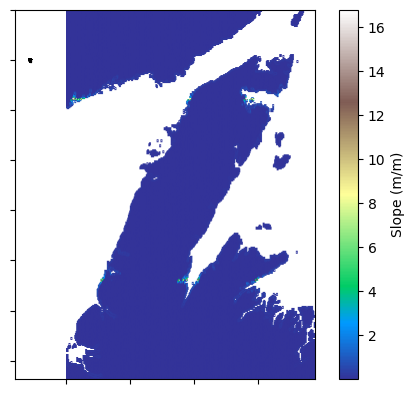

In [ ]:
S = np.asarray(S)
S_masked = np.ma.masked_equal(S, 0)

fig, ax = plt.subplots()
cmap = plt.cm.terrain
cmap.set_bad("white") 

im = ax.imshow(S_masked, cmap=cmap)
fig.colorbar(im, ax=ax, label="Slope (m/m)")
aoi.boundary.plot(ax = ax, edgecolor = "k")
ax.set_xticklabels([])
ax.set_yticklabels([]);